In [6]:
import pandas as pd

data = pd.read_excel("../data/pakistan_aqi.xlsx")



In [7]:
pm25_data = data[data["Type"] == "PM 2.5"]

pm25_data.head()
pm25_data.shape

(1367, 4)

In [8]:
pm25_data.to_csv("../data/pakistan_pm25_clean.csv", index=False)

In [9]:
pm25_data.to_csv("../data/pakistan_pm25_clean.csv", index=False)

In [54]:
import os

DATA_PATH = os.path.join("..", "data", "pakistan_aqi.xlsx")

data = pd.read_excel(DATA_PATH)

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1367 non-null   datetime64[ns]
 1   City    1367 non-null   object        
 2   Type    1367 non-null   object        
 3   Count   1367 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 42.8+ KB


In [10]:
data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


In [11]:
data.columns

Index(['Date', 'City', 'Type', 'Count'], dtype='object')

In [12]:
data["Type"].value_counts()


Type
PM 2.5    1367
Name: count, dtype: int64

In [13]:
pm25_data = data[data["Type"] == "PM 2.5"]

pm25_data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


In [14]:
pm25_data.shape

(1367, 4)

In [15]:
pm25_data["City"].value_counts()

City
Islamabad    358
Lahore       347
Karachi      333
Peshawar     329
Name: count, dtype: int64

In [17]:
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])
pm25_data.dtypes


Date     datetime64[ns]
City             object
Type             object
Count            object
dtype: object

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

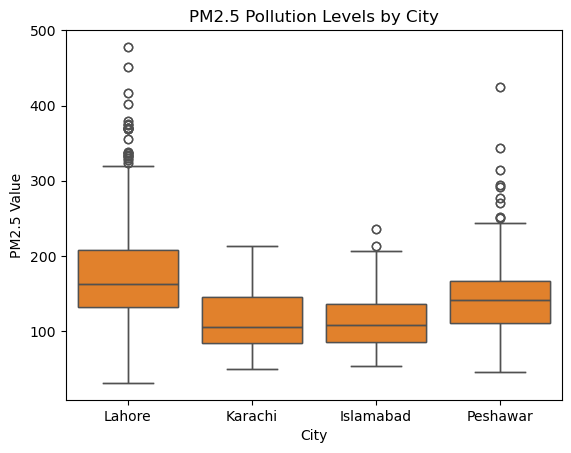

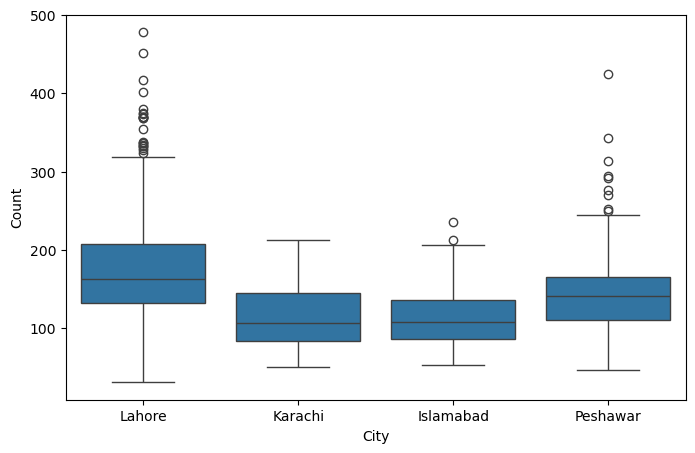

In [19]:

pm25_data["Count"] = pm25_data["Count"].replace("-", None)


pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])


pm25_data = pm25_data.dropna(subset=["Count"])


pm25_data.dtypes


sns.boxplot(x="City", y="Count", data=pm25_data)

sns.boxplot(x="City", y="Count", data=pm25_data)

plt.title("PM2.5 Pollution Levels by City")
plt.xlabel("City")
plt.ylabel("PM2.5 Value")


plt.figure(figsize=(8,5))

sns.boxplot(x="City", y="Count", data=pm25_data)



plt.savefig("../images/pollution_by_city.png")

plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
data = pd.read_excel("../data/pakistan_aqi.xlsx")
data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


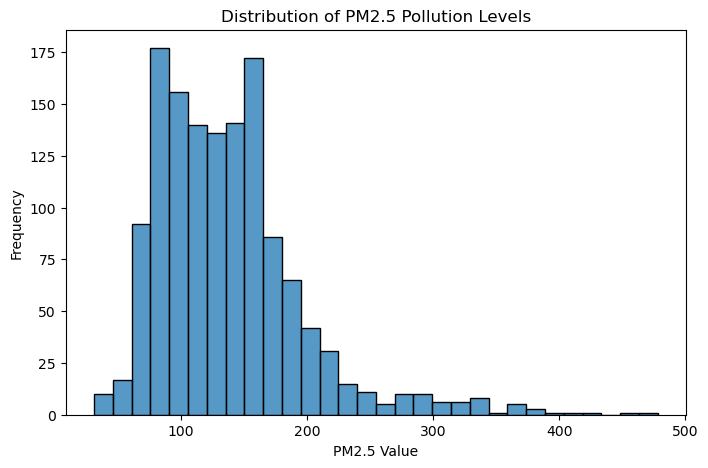

In [22]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 data
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column to datetime
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean Count column
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])
pm25_data = pm25_data.dropna(subset=["Count"])

# Create histogram

plt.figure(figsize=(8,5))

sns.histplot(pm25_data["Count"], bins=30)

plt.title("Distribution of PM2.5 Pollution Levels")
plt.xlabel("PM2.5 Value")
plt.ylabel("Frequency")

plt.savefig("../images/pm25_distribution.png")

plt.show()

In [23]:
city_avg = pm25_data.groupby("City")["Count"].mean()

city_avg

City
Islamabad    113.853521
Karachi      113.655385
Lahore       178.612245
Peshawar     143.446483
Name: Count, dtype: float64

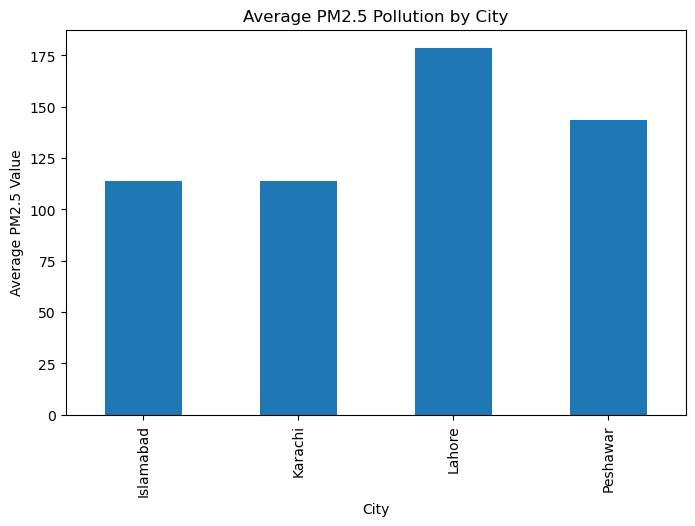

In [24]:
plt.figure(figsize=(8,5))

city_avg.plot(kind="bar")

plt.title("Average PM2.5 Pollution by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5 Value")

plt.savefig("../images/avg_pollution_by_city.png")

plt.show()

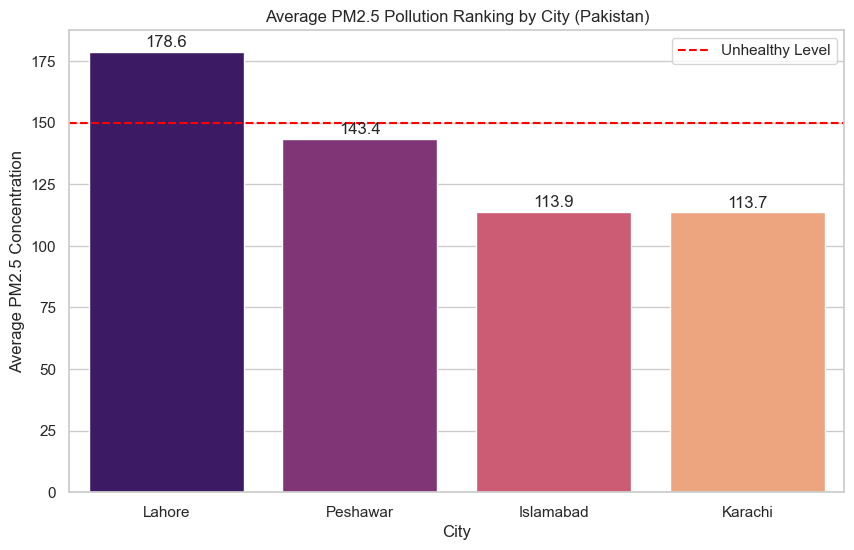

In [25]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
# Calculate average pollution per city
city_avg = pm25_data.groupby("City")["Count"].mean()

# Sort cities by pollution level
city_avg_sorted = city_avg.sort_values(ascending=False)

city_avg_sorted
ax = sns.barplot(
    x=city_avg_sorted.index,
    y=city_avg_sorted.values,
    hue=city_avg_sorted.index,   # assign hue
    palette="magma",
    legend=False                 # hide duplicate legend
)

# Add value labels
for i, value in enumerate(city_avg_sorted.values):
    ax.text(i, value + 2, f"{value:.1f}", ha="center")

# Reference line
plt.axhline(150, color="red", linestyle="--", label="Unhealthy Level")

plt.title("Average PM2.5 Pollution Ranking by City (Pakistan)")
plt.xlabel("City")
plt.ylabel("Average PM2.5 Concentration")

plt.legend()

plt.savefig("../images/pollution_city_ranking_advanced.png")

plt.show()


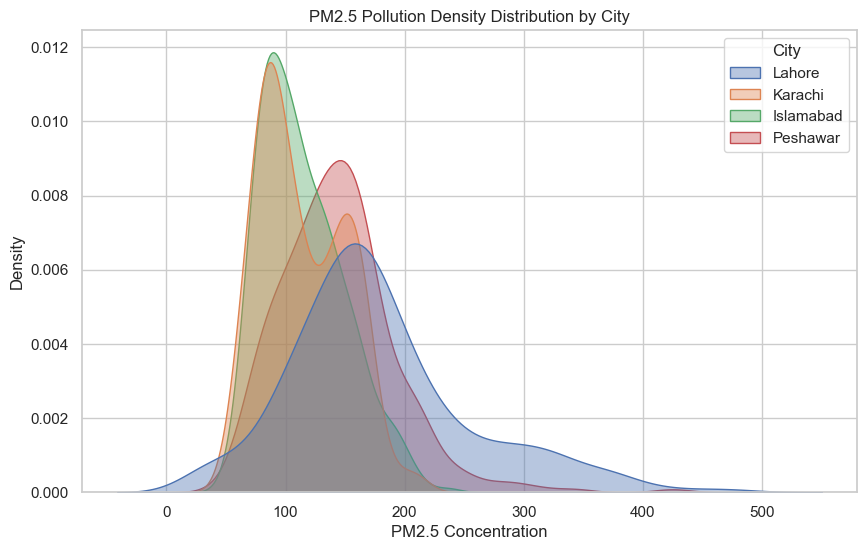

In [26]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

sns.kdeplot(
    data=pm25_data,
    x="Count",
    hue="City",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("PM2.5 Pollution Density Distribution by City")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Density")

plt.savefig("../images/pollution_density_city.png")

plt.show()

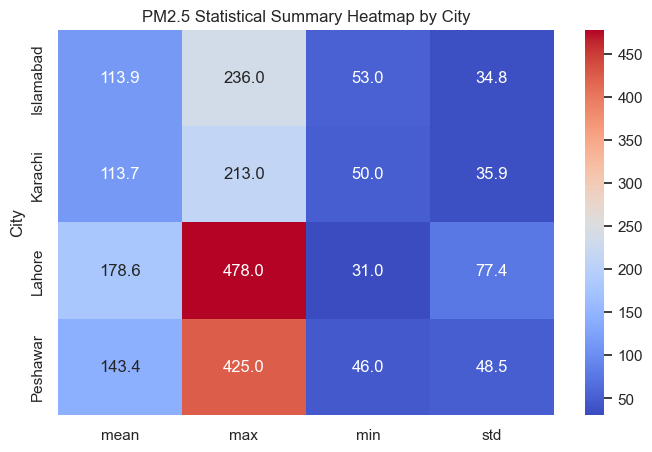

In [27]:
# Create statistical summary
city_stats = pm25_data.groupby("City")["Count"].agg(["mean","max","min","std"])

plt.figure(figsize=(8,5))

sns.heatmap(
    city_stats,
    annot=True,
    cmap="coolwarm",
    fmt=".1f"
)

plt.title("PM2.5 Statistical Summary Heatmap by City")

plt.savefig("../images/pollution_heatmap_city.png")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12720\2568707378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


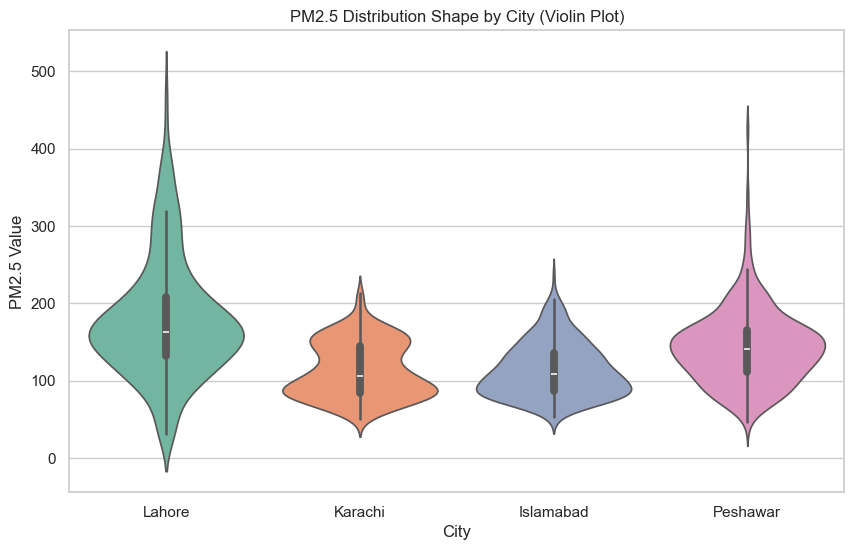

In [28]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

sns.violinplot(
    data=pm25_data,
    x="City",
    y="Count",
    palette="Set2"
)

plt.title("PM2.5 Distribution Shape by City (Violin Plot)")
plt.xlabel("City")
plt.ylabel("PM2.5 Value")

plt.savefig("../images/pollution_violin_city.png")

plt.show()

<Figure size 1000x600 with 0 Axes>

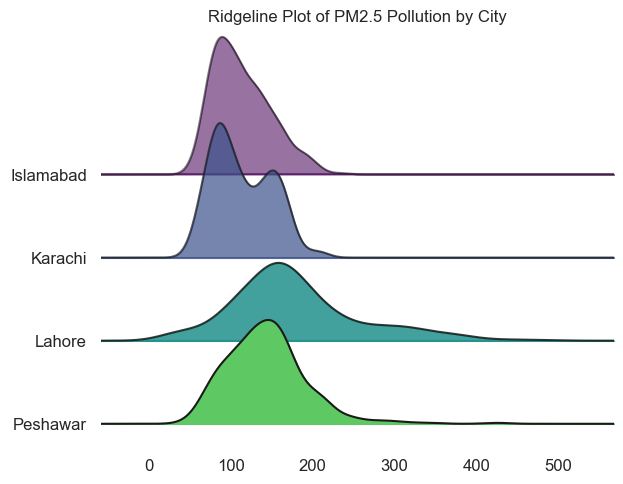

In [29]:
import joypy
plt.figure(figsize=(10,6))

joypy.joyplot(
    data=pm25_data,
    by="City",
    column="Count",
    colormap=plt.cm.viridis,
    fade=True
)

plt.title("Ridgeline Plot of PM2.5 Pollution by City")

plt.savefig("../images/pollution_ridgeline_city.png")

plt.show()

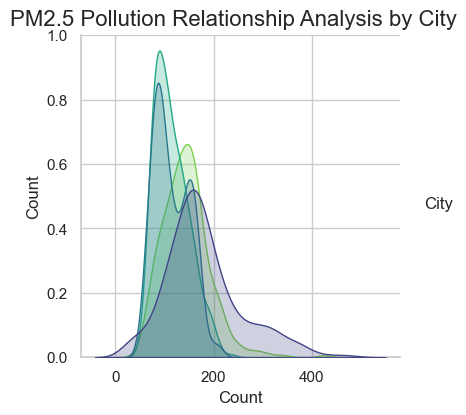

In [30]:
pairplot_data = pm25_data[["City", "Count"]]

pairplot_data.head()
sns.set_theme(style="whitegrid")

pairplot = sns.pairplot(
    pairplot_data,
    hue="City",
    palette="viridis",
    height=4,          # controls size of each subplot
    diag_kind="kde",   # smoother distribution
    plot_kws={"alpha":0.6, "s":60}  # marker transparency + size
)

pairplot.fig.suptitle(
    "PM2.5 Pollution Relationship Analysis by City",
    y=1.02,
    fontsize=16
)

pairplot.savefig("../images/pollution_pairplot_city.png")

plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 data
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column to datetime
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean pollution values
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])
pm25_data = pm25_data.dropna(subset=["Count"])

pm25_data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231.0
1,2019-05-11,Lahore,PM 2.5,171.0
2,2019-05-12,Lahore,PM 2.5,209.0
3,2019-05-13,Lahore,PM 2.5,188.0
4,2019-05-14,Lahore,PM 2.5,194.0


In [32]:
# Create daily PM2.5 time-series dataset
daily_pm25 = pm25_data.groupby("Date")["Count"].mean()

daily_pm25.head()

Date
2019-04-29    162.0
2019-04-30    124.0
2019-05-01     89.0
2019-05-02     87.0
2019-05-03     69.0
Name: Count, dtype: float64

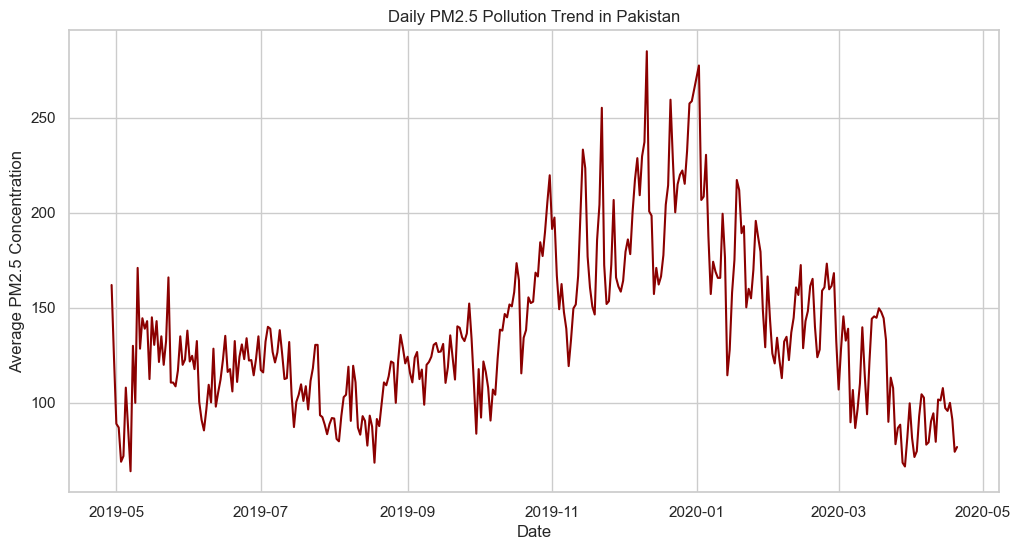

In [33]:
plt.figure(figsize=(12,6))

sns.lineplot(x=daily_pm25.index, y=daily_pm25.values, color="darkred")

plt.title("Daily PM2.5 Pollution Trend in Pakistan")
plt.xlabel("Date")
plt.ylabel("Average PM2.5 Concentration")

plt.grid(True)

plt.show()

In [34]:
city_daily_pm25 = pm25_data.groupby(["Date","City"])["Count"].mean().reset_index()

city_daily_pm25.head()

,Date,City,Count
0,2019-04-29,Islamabad,162.0
1,2019-04-30,Islamabad,124.0
2,2019-05-01,Islamabad,89.0
3,2019-05-02,Islamabad,87.0
4,2019-05-03,Islamabad,69.0


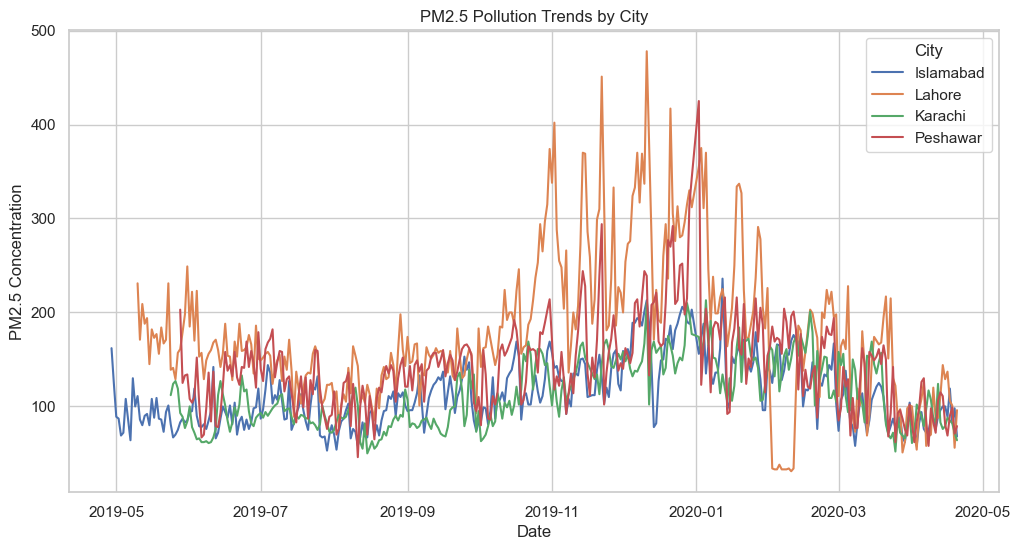

In [35]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=city_daily_pm25,
    x="Date",
    y="Count",
    hue="City"
)

plt.title("PM2.5 Pollution Trends by City")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.grid(True)

plt.savefig("../images/pm25_city_trends.png")

plt.show()

In [36]:
rolling_pm25 = daily_pm25.rolling(window=7).mean()

rolling_pm25.head()

Date
2019-04-29   NaN
2019-04-30   NaN
2019-05-01   NaN
2019-05-02   NaN
2019-05-03   NaN
Name: Count, dtype: float64

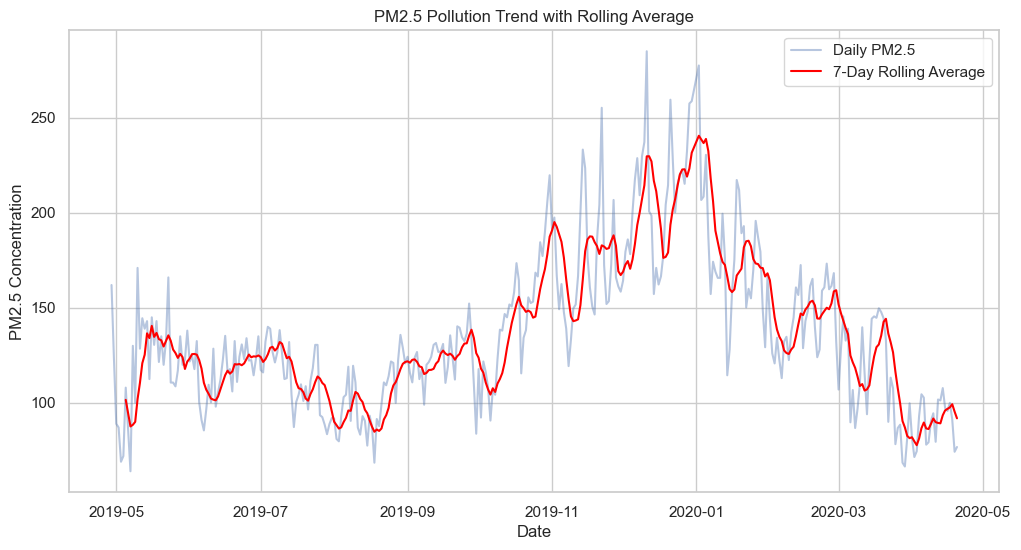

In [37]:
plt.figure(figsize=(12,6))

sns.lineplot(x=daily_pm25.index, y=daily_pm25.values, label="Daily PM2.5", alpha=0.4)

sns.lineplot(x=rolling_pm25.index, y=rolling_pm25.values, color="red", label="7-Day Rolling Average")

plt.title("PM2.5 Pollution Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.grid(True)

plt.savefig("../images/pm25_rolling_average.png")

plt.show()

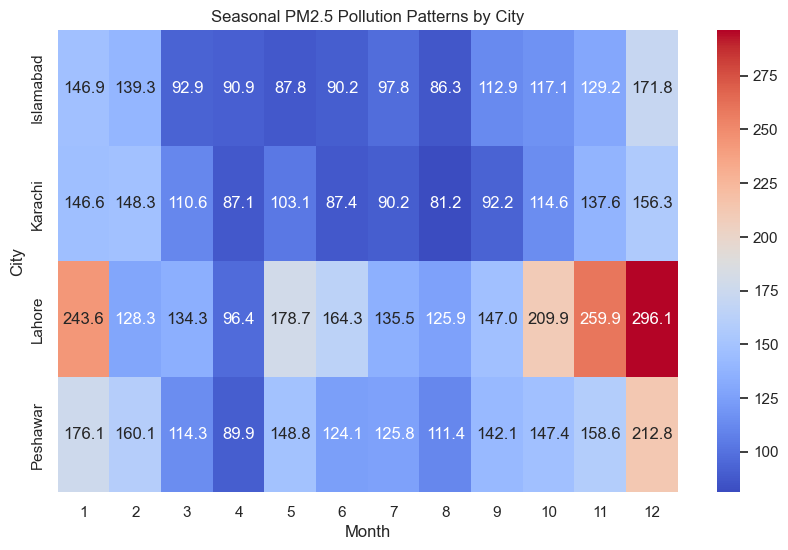

In [38]:
pm25_data["Month"] = pm25_data["Date"].dt.month

pm25_data.head()

monthly_city_pm25 = pm25_data.groupby(["City","Month"])["Count"].mean().unstack()

monthly_city_pm25

plt.figure(figsize=(10,6))

sns.heatmap(
    monthly_city_pm25,
    cmap="coolwarm",
    annot=True,
    fmt=".1f"
)

plt.title("Seasonal PM2.5 Pollution Patterns by City")
plt.xlabel("Month")
plt.ylabel("City")

plt.savefig("../images/pm25_seasonal_heatmap.png")

plt.show()

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 records
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean pollution values
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])
pm25_data = pm25_data.dropna(subset=["Count"])

pm25_data.head()


pm25_data["Year"] = pm25_data["Date"].dt.year
pm25_data["Month"] = pm25_data["Date"].dt.month
pm25_data["Day"] = pm25_data["Date"].dt.day
pm25_data["Weekday"] = pm25_data["Date"].dt.weekday

pm25_data.head()

pm25_data = pd.get_dummies(pm25_data, columns=["City"])

pm25_data.head()

,Date,Type,Count,Year,Month,Day,Weekday,City_Islamabad,City_Karachi,City_Lahore,City_Peshawar
0,2019-05-10,PM 2.5,231.0,2019,5,10,4,False,False,True,False
1,2019-05-11,PM 2.5,171.0,2019,5,11,5,False,False,True,False
2,2019-05-12,PM 2.5,209.0,2019,5,12,6,False,False,True,False
3,2019-05-13,PM 2.5,188.0,2019,5,13,0,False,False,True,False
4,2019-05-14,PM 2.5,194.0,2019,5,14,1,False,False,True,False


In [40]:
X = pm25_data.drop(columns=["Count","Date","Type"])
y = pm25_data["Count"]

X.head()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1080, 8)
Testing data: (270, 8)


In [41]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred[:10]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 34.24773776686413
RMSE: 46.0829748611744
R2 Score: 0.32832613268621225


In [42]:
import pandas as pd

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 data
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean pollution values
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])

# Remove missing values
pm25_data = pm25_data.dropna(subset=["Count"])

pm25_data.head()

pm25_data["Year"] = pm25_data["Date"].dt.year
pm25_data["Month"] = pm25_data["Date"].dt.month
pm25_data["Day"] = pm25_data["Date"].dt.day
pm25_data["Weekday"] = pm25_data["Date"].dt.weekday

pm25_data = pd.get_dummies(pm25_data, columns=["City"])
from sklearn.model_selection import train_test_split

X = pm25_data.drop(columns=["Count","Date","Type"])
y = pm25_data["Count"]



from sklearn.model_selection import train_test_split

X = pm25_data.drop(columns=["Count","Date","Type"])
y = pm25_data["Count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

(1080, 8)
(270, 8)
Random Forest MAE: 20.32211111111111
Random Forest RMSE: 28.07154600632436
Random Forest R2: 0.7507643855752906


C:\Users\HP\AppData\Local\Temp\ipykernel_12720\31741658.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


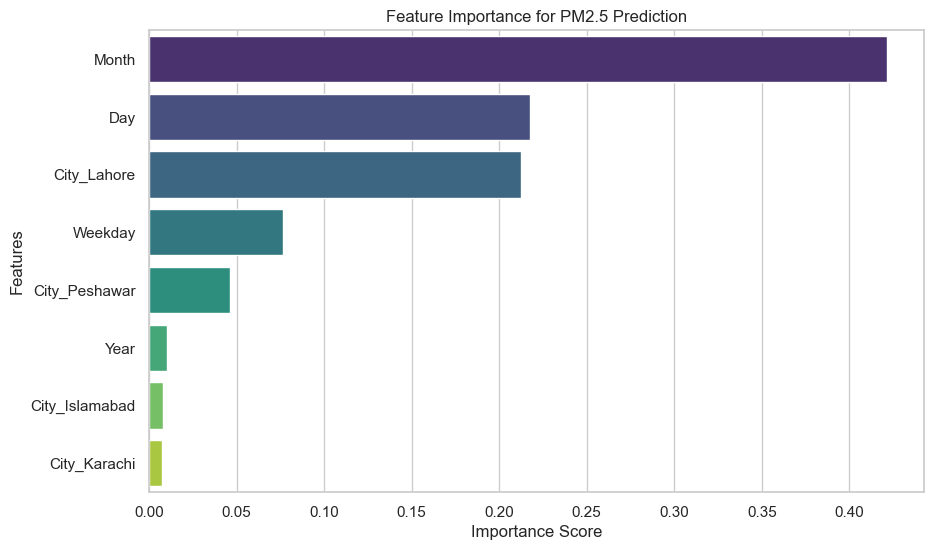

In [43]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index,
    palette="viridis"
)

plt.title("Feature Importance for PM2.5 Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.savefig("../images/feature_importance.png")

plt.show()

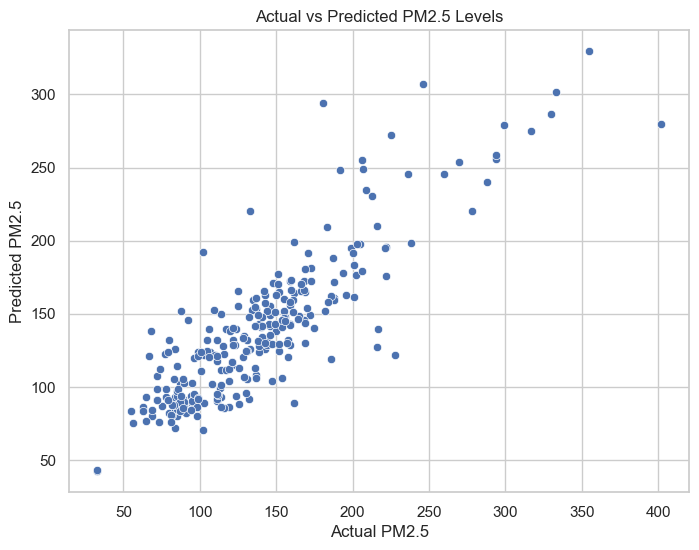

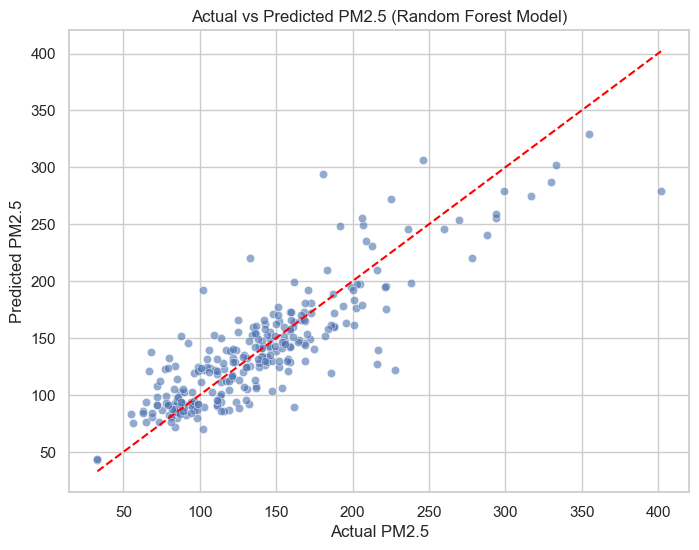

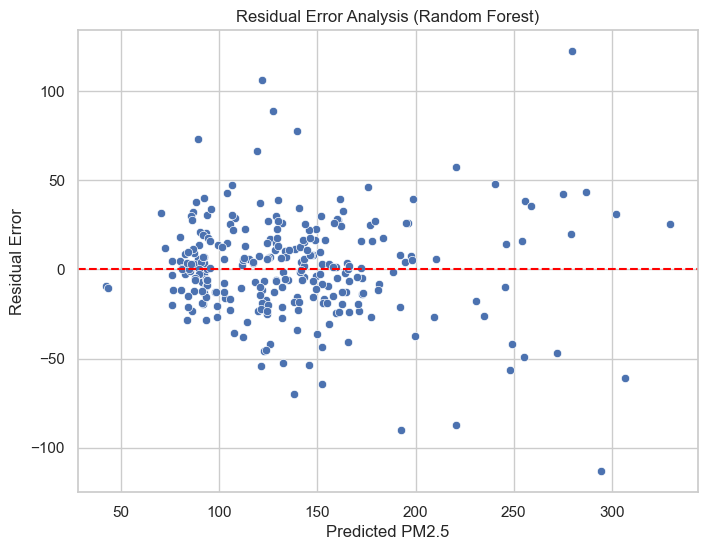

,Actual,Predicted,Error
176,402.0,279.62,122.38
198,181.0,294.22,113.22
300,228.0,121.94,106.06
1217,102.0,192.32,90.32
1268,216.0,127.29,88.71
1236,133.0,220.44,87.44
316,217.0,139.47,77.53
680,162.0,89.07,72.93
1337,68.0,138.02,70.02
279,186.0,119.43,66.57


In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=rf_pred)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5 Levels")

plt.grid(True)

plt.show()


plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=rf_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5 (Random Forest Model)")

plt.grid(True)

plt.savefig("../images/actual_vs_predicted.png")

plt.show()

residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

sns.scatterplot(x=rf_pred, y=residuals)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual Error")

plt.title("Residual Error Analysis (Random Forest)")

plt.grid(True)

plt.savefig("../images/residual_analysis.png")

plt.show()

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred
})

error_df["Error"] = abs(error_df["Actual"] - error_df["Predicted"])

error_df.sort_values("Error", ascending=False).head(10)

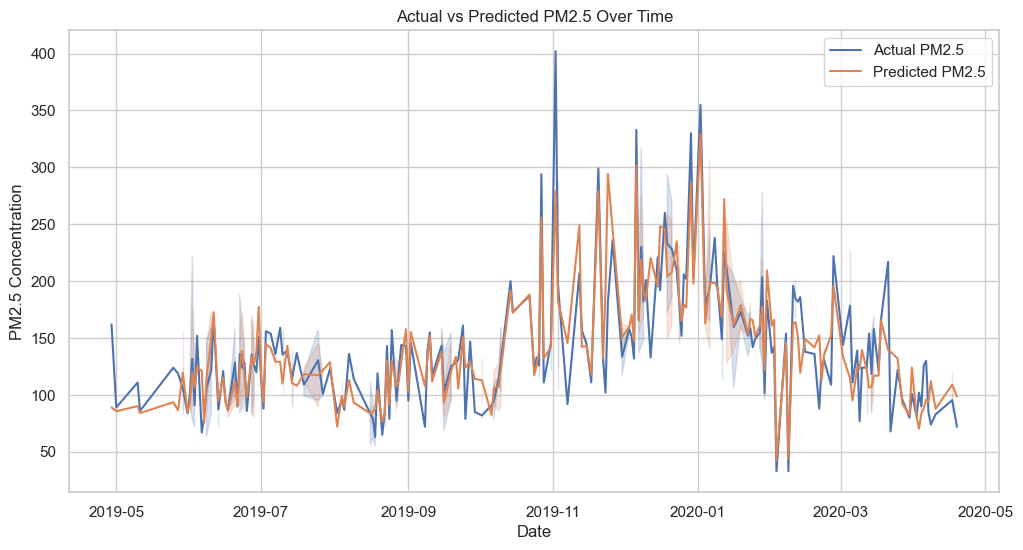

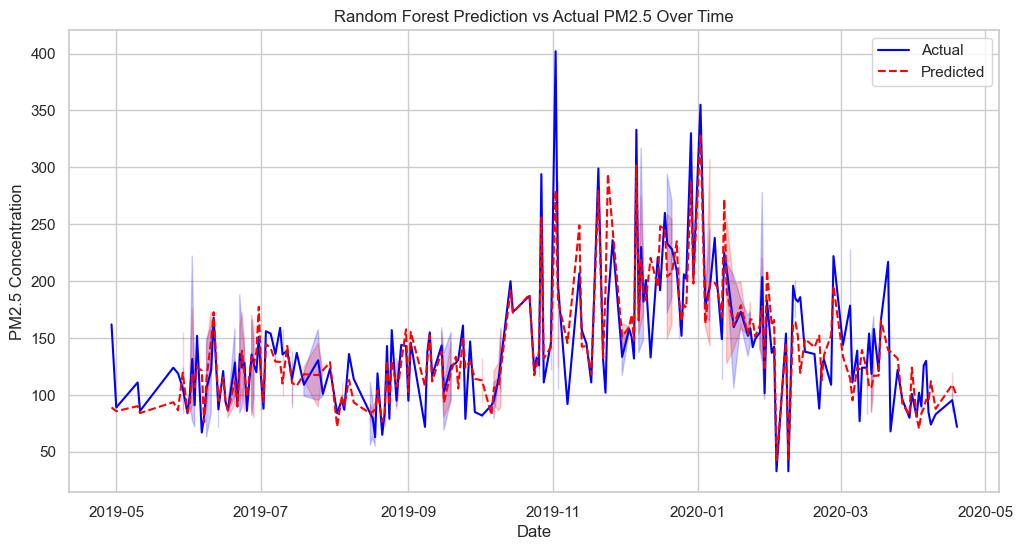

In [45]:
y_test
rf_pred
results_df = pd.DataFrame({
    "Date": pm25_data.loc[y_test.index, "Date"],
    "Actual_PM25": y_test,
    "Predicted_PM25": rf_pred
})

results_df = results_df.sort_values("Date")

results_df.head()


plt.figure(figsize=(12,6))

sns.lineplot(
    data=results_df,
    x="Date",
    y="Actual_PM25",
    label="Actual PM2.5"
)

sns.lineplot(
    data=results_df,
    x="Date",
    y="Predicted_PM25",
    label="Predicted PM2.5"
)

plt.title("Actual vs Predicted PM2.5 Over Time")

plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.grid(True)

plt.show()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=results_df,
    x="Date",
    y="Actual_PM25",
    color="blue",
    label="Actual"
)

sns.lineplot(
    data=results_df,
    x="Date",
    y="Predicted_PM25",
    color="red",
    linestyle="--",
    label="Predicted"
)

plt.title("Random Forest Prediction vs Actual PM2.5 Over Time")

plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.grid(True)

plt.savefig("../images/time_prediction_analysis.png")

plt.show()

In [46]:
import pandas as pd

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 data
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert date
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean pollution values
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])

# Remove missing values
pm25_data = pm25_data.dropna(subset=["Count"])

pm25_data.head()


from sklearn.model_selection import train_test_split

X = pm25_data.drop(columns=["Count","Date","Type"])
y = pm25_data["Count"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1080, 1)
Testing shape: (270, 1)


Cross Validation Scores: [-0.58145355 -1.21454482  0.32871307  0.12319077  0.19573467]
Average R2 Score: -0.22967197219312782


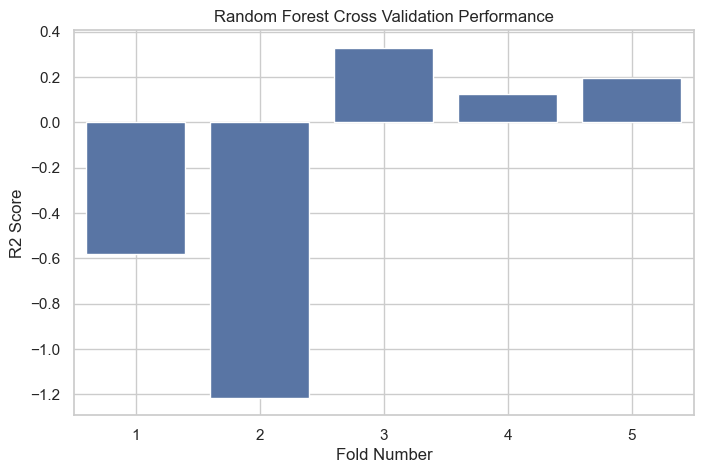

In [47]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor


# ===============================
# 2. Load Dataset
# ===============================
data = pd.read_excel("../data/pakistan_aqi.xlsx")


# ===============================
# 3. Filter PM2.5 Data
# ===============================
pm25_data = data[data["Type"] == "PM 2.5"]


# ===============================
# 4. Data Cleaning
# ===============================
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])

pm25_data = pm25_data.dropna(subset=["Count"])


# ===============================
# 5. Feature Engineering
# ===============================
pm25_data["Year"] = pm25_data["Date"].dt.year
pm25_data["Month"] = pm25_data["Date"].dt.month
pm25_data["Day"] = pm25_data["Date"].dt.day
pm25_data["Weekday"] = pm25_data["Date"].dt.weekday


# ===============================
# 6. Encode City Column
# ===============================
pm25_data = pd.get_dummies(pm25_data, columns=["City"])


# ===============================
# 7. Define Features and Target
# ===============================
X = pm25_data.drop(columns=["Count", "Date", "Type"])
y = pm25_data["Count"]


# ===============================
# 8. Train Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# ===============================
# 9. Train Random Forest Model
# ===============================
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


# ===============================
# 10. Cross Validation
# ===============================
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores)
print("Average R2 Score:", cv_scores.mean())


# ===============================
# 11. Cross Validation Visualization
# ===============================
plt.figure(figsize=(8,5))

sns.barplot(x=list(range(1,6)), y=cv_scores)

plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("Random Forest Cross Validation Performance")

plt.grid(True)

plt.savefig("../images/cross_validation.png")

plt.show()

In [48]:
from sklearn.model_selection import train_test_split

X = pm25_data.drop(columns=["Count","Date","Type"])
y = pm25_data["Count"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

best_rf_model.fit(X_train, y_train)

best_pred = best_rf_model.predict(X_test)

Training shape: (1080, 8)
Testing shape: (270, 8)


In [49]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# LOAD DATASET
# ==============================
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# ==============================
# FILTER PM2.5 DATA
# ==============================
pm25_data = data[data["Type"] == "PM 2.5"]

pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])

pm25_data = pm25_data.dropna(subset=["Count"])

# ==============================
# FEATURE ENGINEERING
# ==============================
pm25_data["Year"] = pm25_data["Date"].dt.year
pm25_data["Month"] = pm25_data["Date"].dt.month
pm25_data["Day"] = pm25_data["Date"].dt.day
pm25_data["Weekday"] = pm25_data["Date"].dt.weekday

# ==============================
# ENCODE CITY
# ==============================
pm25_data = pd.get_dummies(pm25_data, columns=["City"])

# ==============================
# DEFINE FEATURES
# ==============================
X = pm25_data.drop(columns=["Count","Date","Type"])
y = pm25_data["Count"]

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==============================
# LINEAR REGRESSION MODEL
# ==============================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# ==============================
# RANDOM FOREST MODEL
# ==============================
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# ==============================
# EVALUATION
# ==============================
lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression R2:", lr_r2)
print("Random Forest R2:", rf_r2)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [lr_r2, rf_r2]
})

results

Linear Regression R2: 0.32832613268621225
Random Forest R2: 0.7507643855752906


,Model,R2 Score
0,Linear Regression,0.328326
1,Random Forest,0.750764


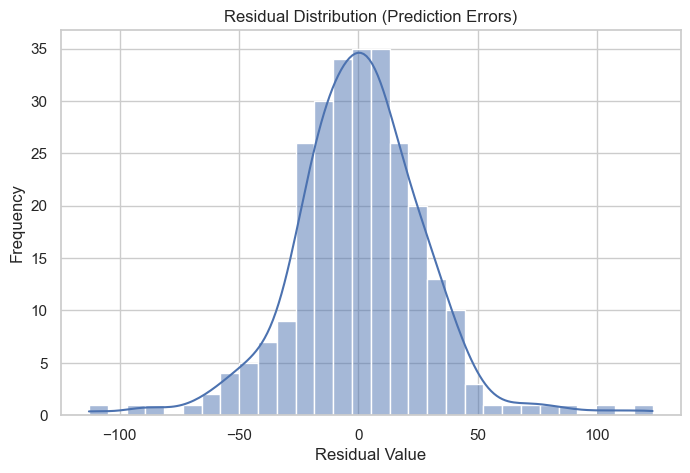

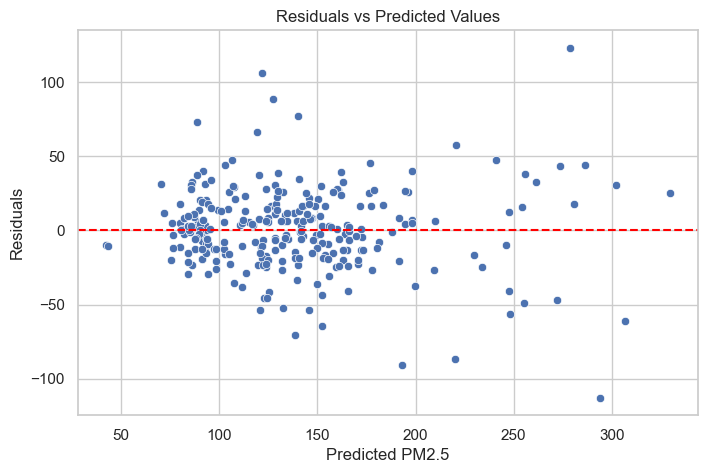

In [50]:
# Calculate residuals
residuals = y_test - best_pred

residuals.head()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution (Prediction Errors)")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")

plt.grid(True)

plt.savefig("../images/residual_distribution.png")

plt.show()

plt.figure(figsize=(8,5))

sns.scatterplot(x=best_pred, y=residuals)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.grid(True)

plt.savefig("../images/residual_vs_predicted.png")

plt.show()

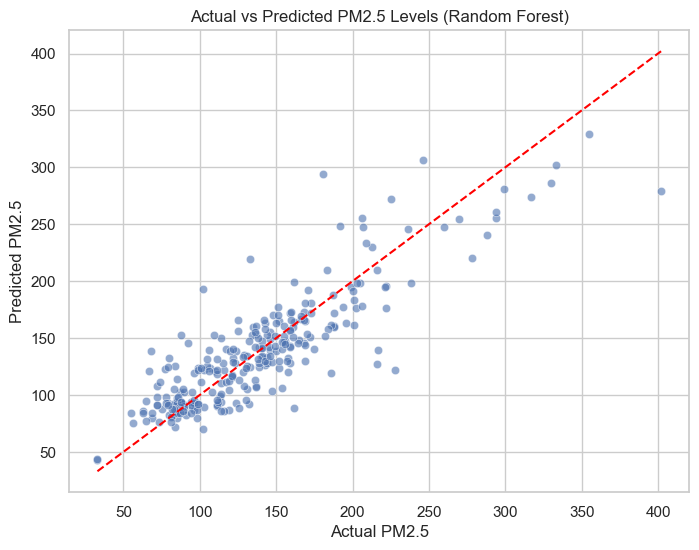

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=best_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5 Levels (Random Forest)")

plt.grid(True)

plt.savefig("../images/actual_vs_predicted.png")

plt.show()

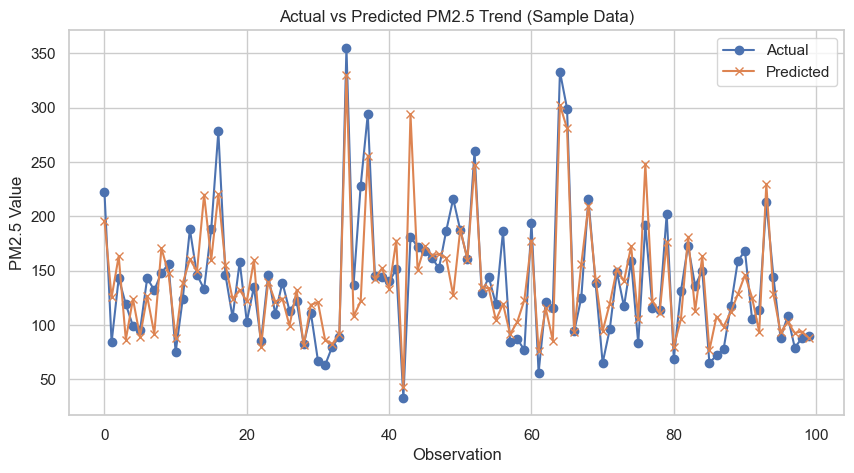

In [52]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label="Actual",
    marker="o"
)

plt.plot(
    best_pred[:100],
    label="Predicted",
    marker="x"
)

plt.title("Actual vs Predicted PM2.5 Trend (Sample Data)")

plt.xlabel("Observation")
plt.ylabel("PM2.5 Value")

plt.legend()

plt.grid(True)

plt.savefig("../images/actual_vs_predicted_trend.png")

plt.show()

In [53]:
import joblib

joblib.dump(best_rf_model, "../models/pm25_prediction_model.pkl")
print("Model saved successfully!")

loaded_model = joblib.load("../models/pm25_prediction_model.pkl")

test_prediction = loaded_model.predict(X_test[:5])

print(test_prediction)

Model saved successfully!
[196.04 125.27 163.29  86.44 123.84]
